# 🛍️ Shopping Mall Customer Segmentation
## Notebook 0 — EDA & Preprocessing

---
### 📌 What is this notebook doing?
Before we can group customers, we need to:
1. **Understand** the data (EDA — Exploratory Data Analysis)
2. **Clean** the data (remove useless columns, fix encoding)
3. **Scale** the data (make all numbers in the same range)
4. **Save** the cleaned data for use by all algorithm notebooks

> ⚠️ **Run this notebook FIRST before any clustering notebooks.**

---
## Step 1: Import Libraries
We load all the tools we need before starting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('✅ Libraries loaded!')

✅ Libraries loaded!


---
## Step 2: Load Dataset

In [2]:
df = pd.read_csv('Shopping_Mall_Customer_Segmentation_Data_.csv')
print(f'Total customers : {len(df):,}')
print(f'Total features  : {df.shape[1]}')
print()
df.head(10)

Total customers : 15,079
Total features  : 5



,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76
5,7e211337-e92f-4140-8231-5c9ac7a2aa12,42,Male,158335,40
6,30661d57-eeb5-4886-970a-9c7d0f260ad8,27,Female,163501,37
7,43417ade-6b17-431e-ae76-d8ed26aa46ac,24,Male,70476,17
8,86f73b1a-6a91-4d7e-ad21-0aefcf6111cc,83,Male,47743,34
9,b20fe0a0-e254-4116-b804-5403bb2f59ea,62,Female,63448,3


---
## Step 3: Basic Dataset Overview

In [3]:
print('--- Column Data Types ---')
df.info()
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Duplicate Rows ---')
print(f'Duplicates: {df.duplicated().sum()}')

--- Column Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB

--- Missing Values ---
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

--- Duplicate Rows ---
Duplicates: 0


In [4]:
print('--- Statistical Summary ---')
df.describe().round(2)

--- Statistical Summary ---


,Age,Annual Income,Spending Score
count,15079.00,15079.00,15079.00
mean,54.19,109742.88,50.59
std,21.12,52249.43,28.73
min,18.00,20022.00,1.00
25%,36.00,64141.00,26.00
50%,54.00,109190.00,51.00
75%,72.00,155008.00,75.00
max,90.00,199974.00,100.00


---
# PART 1 — EDA (Exploratory Data Analysis)

### 📌 Why do we do EDA?
EDA is like inspecting ingredients before cooking.
We need to know:
- What does each column look like? (distribution)
- Are there any extreme/weird values? (outliers)
- Are any features related to each other? (correlation)
- Can we already see natural groups in the data? (scatter plots)

**All of this directly informs how we preprocess and cluster the data.**

### Plot 1: Feature Distributions
**Purpose:** Understand the spread of each numeric feature.
- If data is heavily skewed, it can confuse clustering algorithms.
- The mean and median lines tell us about symmetry.

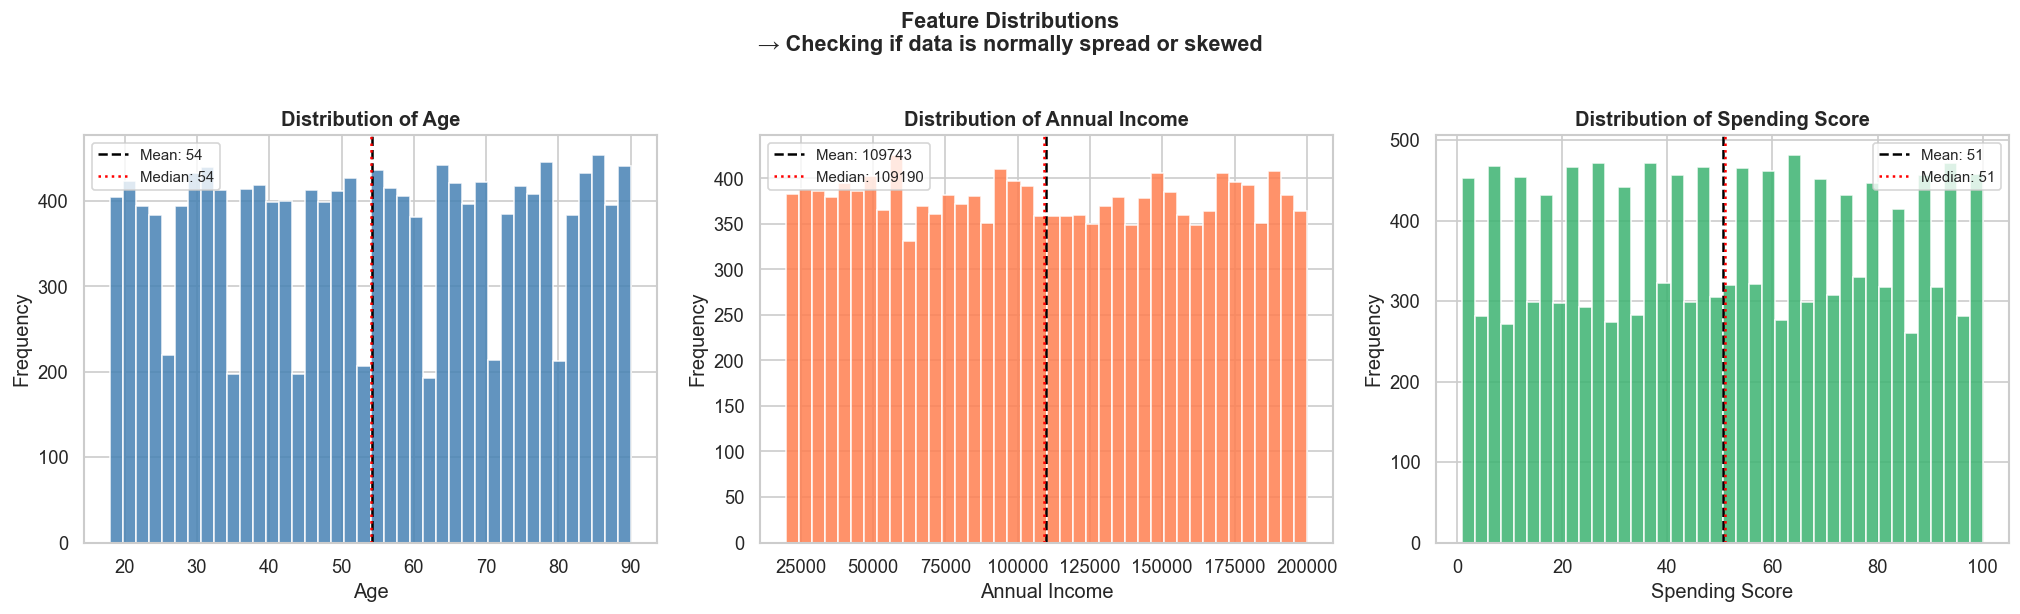

📊 Interpretation:
   Age           — fairly uniform spread (18–90)
   Annual Income — roughly uniform (20k–200k)
   Spending Score— roughly uniform (1–100)
   → No severe skew detected. Data is suitable for clustering.


In [5]:
numeric_cols = ['Age', 'Annual Income', 'Spending Score']
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col, color in zip(axes, numeric_cols, colors):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='black', linestyle='--', lw=1.5, label=f'Mean: {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='red',   linestyle=':',  lw=1.5, label=f'Median: {df[col].median():.0f}')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions\n→ Checking if data is normally spread or skewed', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   Age           — fairly uniform spread (18–90)')
print('   Annual Income — roughly uniform (20k–200k)')
print('   Spending Score— roughly uniform (1–100)')
print('   → No severe skew detected. Data is suitable for clustering.')

### Plot 2: Gender Distribution
**Purpose:** Check if gender is balanced.
- If one gender heavily dominates, it could bias the clusters.
- The bar chart shows if Male/Female customers have different average Income and Spending Score — this tells us whether Gender is a useful feature for segmentation.

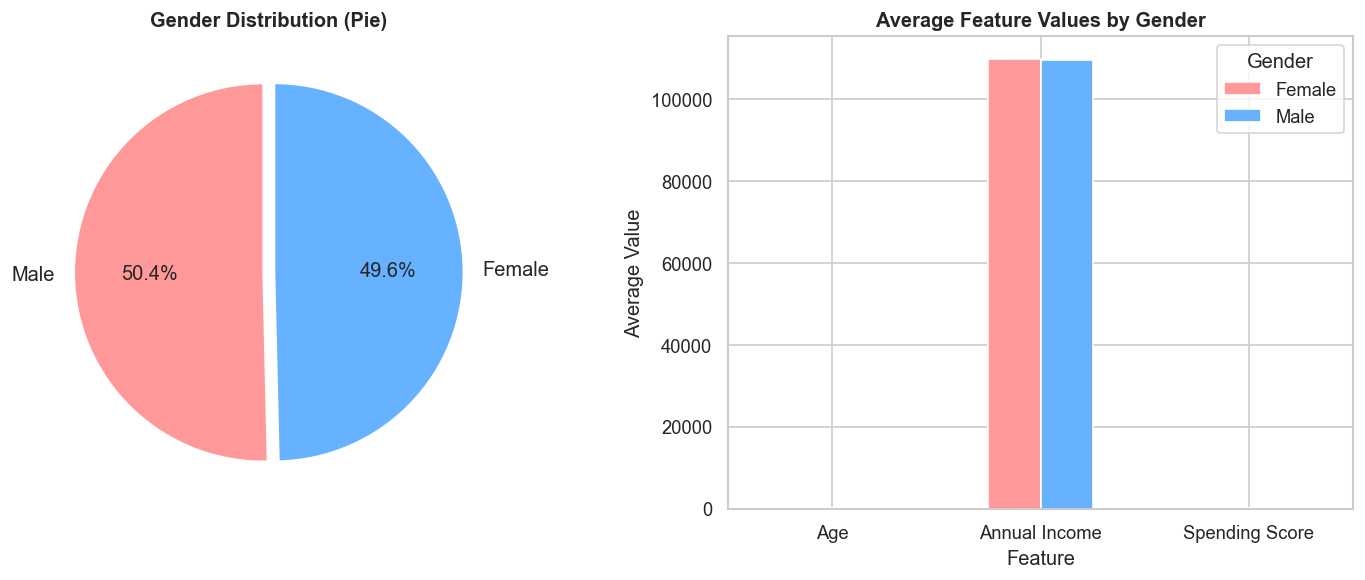

📊 Interpretation:
   → If average Income and Spending Score are similar for Male/Female,
     Gender does not significantly affect cluster formation.
   → If they differ, Gender is an important segmentation feature.


In [6]:
gender_counts = df['Gender'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
gender_counts.plot.pie(ax=axes[0], autopct='%1.1f%%',
                       colors=['#FF9999','#66B2FF'],
                       startangle=90, explode=[0.03, 0.03],
                       textprops={'fontsize': 12})
axes[0].set_title('Gender Distribution (Pie)', fontweight='bold')
axes[0].set_ylabel('')

# Average feature values by Gender
gender_means = df.groupby('Gender')[numeric_cols].mean().round(0)
gender_means.T.plot(kind='bar', ax=axes[1], color=['#FF9999','#66B2FF'], edgecolor='white')
axes[1].set_title('Average Feature Values by Gender', fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Average Value')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig('eda_gender.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   → If average Income and Spending Score are similar for Male/Female,')
print('     Gender does not significantly affect cluster formation.')
print('   → If they differ, Gender is an important segmentation feature.')

### Plot 3: Box Plots — Outlier Detection
**Purpose:** Find extreme values (outliers) that could distort clustering.
- Clustering algorithms like K-Means are sensitive to outliers.
- If a customer has an extremely unusual value, they might form their own cluster or pull other clusters towards them.
- The box shows the middle 50% of data. Dots outside the whiskers = outliers.

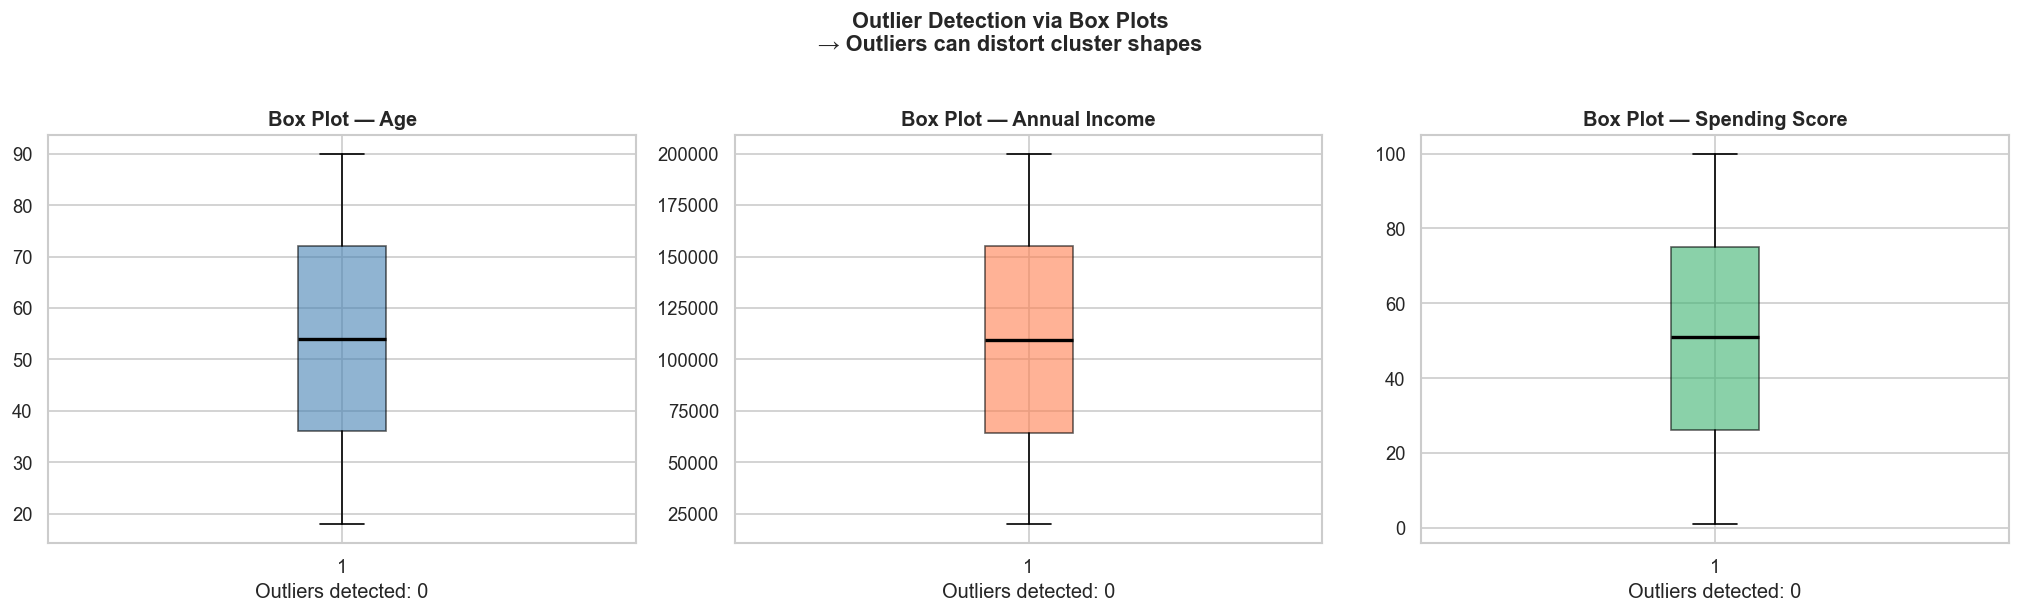

📊 Interpretation:
   → Any extreme outliers found will be removed in preprocessing
     to prevent them from skewing the cluster boundaries.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col, color in zip(axes, numeric_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.3))
    ax.set_title(f'Box Plot — {col}', fontweight='bold')
    ax.set_xlabel(col)

    # Count outliers using IQR method
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f'Outliers detected: {n_outliers}')

plt.suptitle('Outlier Detection via Box Plots\n→ Outliers can distort cluster shapes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   → Any extreme outliers found will be removed in preprocessing')
print('     to prevent them from skewing the cluster boundaries.')

### Plot 4: Scatter Plots — Pre-clustering Visual
**Purpose:** The most important EDA plot for clustering!
- We can already SEE natural groups (clusters) in the data before running any algorithm.
- The clearer the natural groups, the better clustering will work.
- `Annual Income vs Spending Score` is the key plot — it typically shows 5 distinct groups.

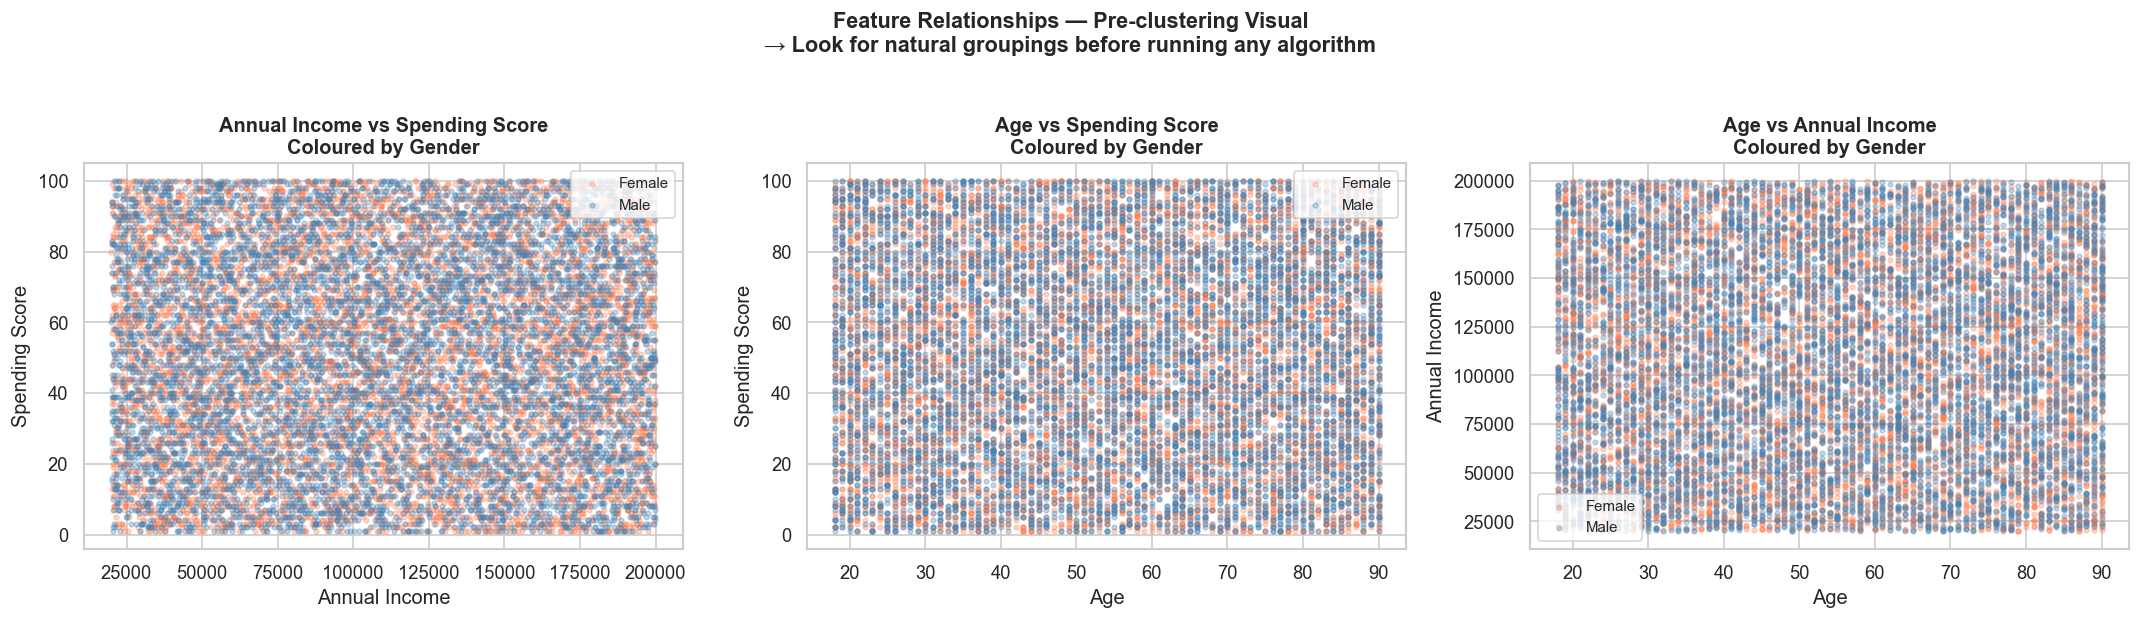

📊 Interpretation:
   Annual Income vs Spending Score:
   → You can already see ~5 natural groups visually:
     • High income + High spend (top right)
     • High income + Low spend  (bottom right)
     • Low income  + High spend (top left)
     • Low income  + Low spend  (bottom left)
     • Medium income + Medium spend (centre)
   → Gender colour shows if male/female cluster differently.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('Annual Income', 'Spending Score'),
         ('Age', 'Spending Score'),
         ('Age', 'Annual Income')]
gender_colors = {'Male': 'steelblue', 'Female': 'coral'}

for ax, (x_col, y_col) in zip(axes, pairs):
    for gender, group in df.groupby('Gender'):
        ax.scatter(group[x_col], group[y_col],
                   color=gender_colors[gender], label=gender, alpha=0.3, s=8)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}\nColoured by Gender', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Feature Relationships — Pre-clustering Visual\n→ Look for natural groupings before running any algorithm',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('eda_scatter.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   Annual Income vs Spending Score:')
print('   → You can already see ~5 natural groups visually:')
print('     • High income + High spend (top right)')
print('     • High income + Low spend  (bottom right)')
print('     • Low income  + High spend (top left)')
print('     • Low income  + Low spend  (bottom left)')
print('     • Medium income + Medium spend (centre)')
print('   → Gender colour shows if male/female cluster differently.')

### Plot 5: Correlation Matrix
**Purpose:** Check if any features are strongly related to each other.
- If two features are highly correlated (e.g. 0.9), they carry the same information — one can be removed.
- For clustering, we want features that are **independent** of each other so each one adds new information.

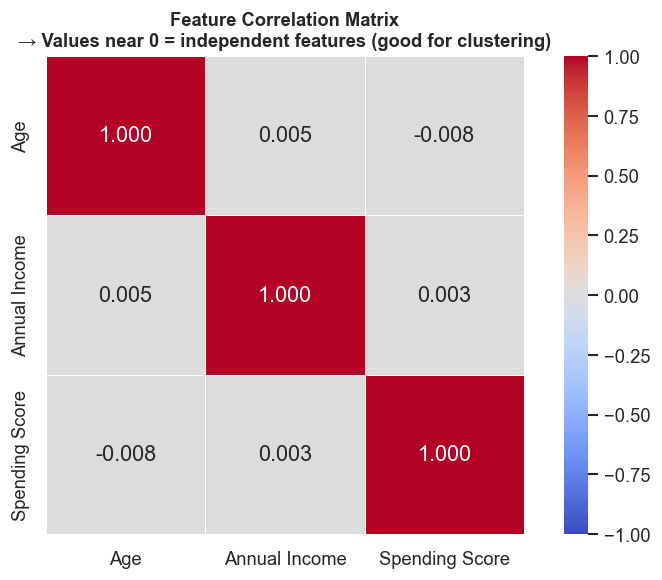

📊 Interpretation:
   → Values between -0.3 and +0.3 = low correlation = each feature
     gives DIFFERENT information to the clustering algorithm.
   → If any value was >0.9, we would consider removing one of the features.


In [9]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True,
            annot_kws={'size': 13})
plt.title('Feature Correlation Matrix\n→ Values near 0 = independent features (good for clustering)',
          fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   → Values between -0.3 and +0.3 = low correlation = each feature')
print('     gives DIFFERENT information to the clustering algorithm.')
print('   → If any value was >0.9, we would consider removing one of the features.')

### Plot 6: 3D Scatter — All Three Features Together
**Purpose:** See how all three numeric features interact at once.
- This gives us the clearest picture of the natural groupings BEFORE clustering.
- Later we will compare this with the cluster results.

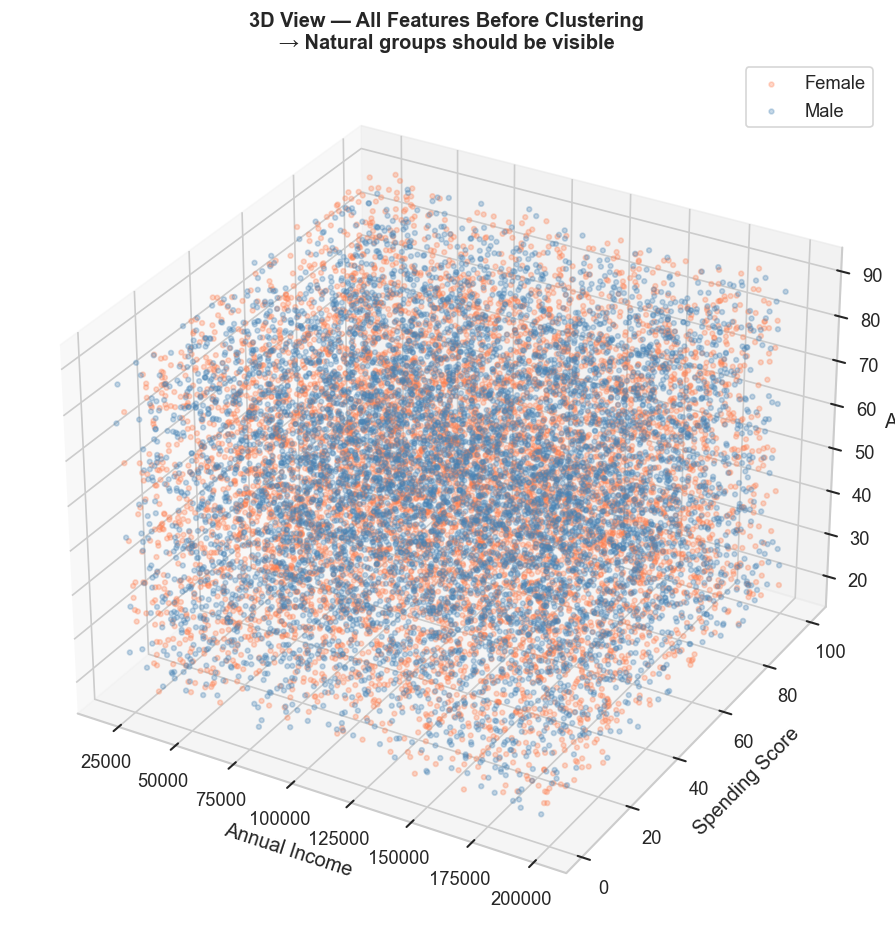

📊 Interpretation:
   → Rotate the 3D view to see if customers naturally separate into groups.
   → After clustering, we will plot this same chart coloured by cluster.


In [10]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

for gender, group in df.groupby('Gender'):
    color = 'steelblue' if gender == 'Male' else 'coral'
    ax.scatter(group['Annual Income'], group['Spending Score'], group['Age'],
               c=color, label=gender, alpha=0.3, s=8)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title('3D View — All Features Before Clustering\n→ Natural groups should be visible', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('eda_3d_scatter.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   → Rotate the 3D view to see if customers naturally separate into groups.')
print('   → After clustering, we will plot this same chart coloured by cluster.')

---
# PART 2 — Data Preprocessing

### 📌 Why do we preprocess?
The raw data cannot be fed directly into clustering algorithms because:
1. **Customer ID** is just a unique code — meaningless for grouping
2. **Gender** is text (Male/Female) — machines only understand numbers
3. **Feature scales differ** — Income is in the hundreds of thousands, but Spending Score is 1–100. Without scaling, Income would dominate and the algorithm would mostly group by Income, ignoring Age and Spending Score.

### Step 10: Drop Customer ID

In [11]:
df_clean = df.drop(columns=['Customer ID'])
print('✅ Dropped: Customer ID')
print('   Reason: UUID with no clustering value — every customer has a unique ID.')
print()
print('Remaining columns:', list(df_clean.columns))

✅ Dropped: Customer ID
   Reason: UUID with no clustering value — every customer has a unique ID.

Remaining columns: ['Age', 'Gender', 'Annual Income', 'Spending Score']


### Step 11: Encode Gender (Text → Number)

In [12]:
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

print('✅ Label Encoding applied to Gender:')
for i, cls in enumerate(le.classes_):
    print(f'   {cls} → {i}')
print()
print('   Reason: Clustering algorithms only understand numbers.')
print('   Male/Female text values are converted to 0/1.')
df_clean.head(3)

✅ Label Encoding applied to Gender:
   Female → 0
   Male → 1

   Reason: Clustering algorithms only understand numbers.
   Male/Female text values are converted to 0/1.


,Age,Gender,Annual Income,Spending Score
0,30,1,151479,89
1,58,0,185088,95
2,62,0,70912,76


### Step 12: Handle Missing Values

In [13]:
print('Missing values check:')
print(df_clean.isnull().sum())
if df_clean.isnull().sum().sum() == 0:
    print()
    print('✅ No missing values found — no imputation needed.')
else:
    df_clean.fillna(df_clean.mean(numeric_only=True), inplace=True)
    print('✅ Missing values filled with column mean.')

Missing values check:
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

✅ No missing values found — no imputation needed.


### Step 13: Feature Scaling — StandardScaler
**Why scaling is critical for clustering:**
- Without scaling: Annual Income (20,000–200,000) vs Spending Score (1–100)
- The algorithm sees Income differences as 1000x more important than Score differences
- After scaling: both become values around -2 to +2, treated equally

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print('Before Scaling — range of each feature:')
for col in df_clean.columns:
    print(f'   {col:20s}: min={df_clean[col].min():.1f}, max={df_clean[col].max():.1f}')

df_scaled_check = pd.DataFrame(X_scaled, columns=df_clean.columns)
print()
print('After Scaling — all features now have mean≈0, std≈1:')
for col in df_scaled_check.columns:
    print(f'   {col:20s}: mean={df_scaled_check[col].mean():.3f}, std={df_scaled_check[col].std():.3f}')

Before Scaling — range of each feature:
   Age                 : min=18.0, max=90.0
   Gender              : min=0.0, max=1.0
   Annual Income       : min=20022.0, max=199974.0
   Spending Score      : min=1.0, max=100.0

After Scaling — all features now have mean≈0, std≈1:
   Age                 : mean=-0.000, std=1.000
   Gender              : mean=-0.000, std=1.000
   Annual Income       : mean=-0.000, std=1.000
   Spending Score      : mean=-0.000, std=1.000


### Plot 7: Before vs After Scaling
**Purpose:** Visually prove that scaling worked — all features now have the same range.

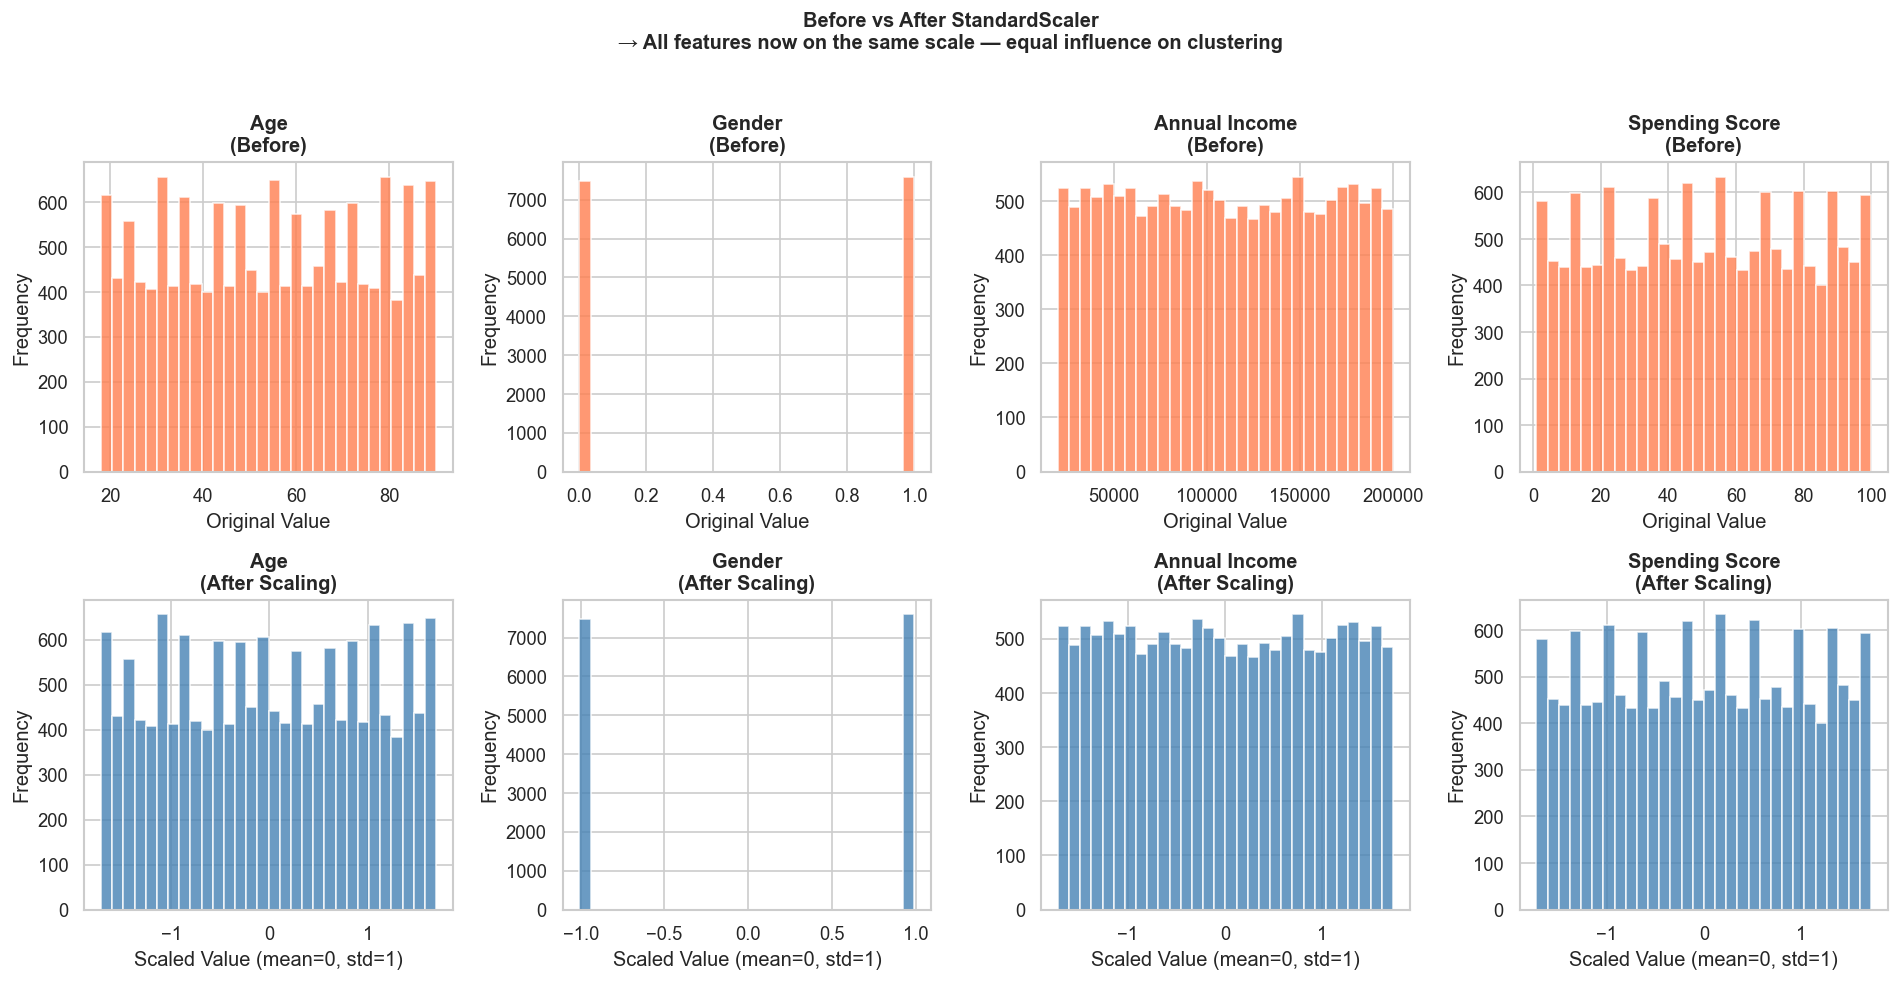

📊 Interpretation:
   Top row  = original values (very different ranges)
   Bottom row = scaled values (all centred around 0)
   → Now all features have EQUAL influence on the clustering algorithm.


In [15]:
all_cols = df_clean.columns.tolist()
n_cols = len(all_cols)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

for i, col in enumerate(all_cols):
    axes[0, i].hist(df_clean[col], bins=30, color='coral', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(Before)', fontweight='bold')
    axes[0, i].set_xlabel('Original Value')
    axes[0, i].set_ylabel('Frequency')

    axes[1, i].hist(df_scaled_check[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(After Scaling)', fontweight='bold')
    axes[1, i].set_xlabel('Scaled Value (mean=0, std=1)')
    axes[1, i].set_ylabel('Frequency')

plt.suptitle('Before vs After StandardScaler\n→ All features now on the same scale — equal influence on clustering',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_scaling.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   Top row  = original values (very different ranges)')
print('   Bottom row = scaled values (all centred around 0)')
print('   → Now all features have EQUAL influence on the clustering algorithm.')

### Step 14: Save Preprocessed Data
We save two files:
- `data_preprocessed.csv` — the cleaned data (for reference and cluster profiling)
- `X_scaled.npy` — the scaled array (this is what the algorithms actually train on)

In [16]:
df_clean.to_csv('data_preprocessed.csv', index=False)
np.save('X_scaled.npy', X_scaled)

print('✅ Saved: data_preprocessed.csv  — cleaned data for cluster profiling')
print('✅ Saved: X_scaled.npy           — scaled array for clustering algorithms')
print()
print('These files will be loaded by:')
print('  → member1_kmeans.ipynb')
print('  → member2_meanshift.ipynb')
print('  → member3_dbscan.ipynb')
print('  → member4_autoencoder.ipynb')
print('  → comparison_all_methods.ipynb')

✅ Saved: data_preprocessed.csv  — cleaned data for cluster profiling
✅ Saved: X_scaled.npy           — scaled array for clustering algorithms

These files will be loaded by:
  → member1_kmeans.ipynb
  → member2_meanshift.ipynb
  → member3_dbscan.ipynb
  → member4_autoencoder.ipynb
  → comparison_all_methods.ipynb


---
## EDA & Preprocessing Summary

| Step | Action | Reason |
|------|--------|--------|
| Drop Customer ID | Removed | UUID — no clustering value |
| Encode Gender | Female=0, Male=1 | Algorithms only understand numbers |
| Handle nulls | None found | Dataset is clean |
| StandardScaler | Applied | Equalise feature influence on clustering |

**Ready to cluster!** Proceed to the individual algorithm notebooks.